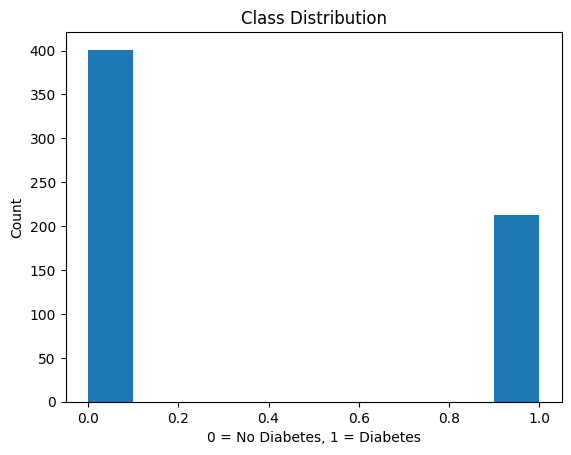

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('diabetes_train.csv')

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols] = df[cols].replace(0, np.nan)
df.fillna(df.mean(), inplace=True)

plt.hist(df["Outcome"])
plt.title("Class Distribution")
plt.xlabel("0 = No Diabetes, 1 = Diabetes")
plt.ylabel("Count")
plt.show()

(768, 8)
(768,)


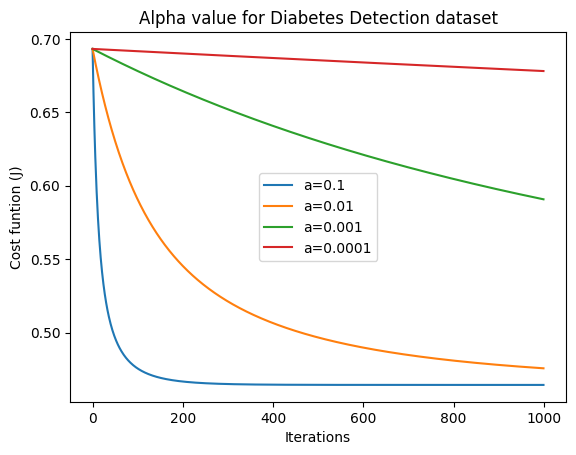

In [12]:
df = pd.read_csv('diabetes_dataset.csv')

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]  # we have done data cleaning here, pregnancies can be zero its alr
df[cols] = df[cols].replace(0, np.nan)  #here we have replaced all values in mentioned features which cant have 0
df.fillna(df.mean(), inplace=True) #replaced features with mean

x1=df["Pregnancies"].to_numpy()
x2= df['Glucose'].to_numpy()
x3= df['BloodPressure'].to_numpy()
x4= df['SkinThickness'].to_numpy()
x5= df['Insulin'].to_numpy()
x6= df['BMI'].to_numpy()
x7= df['Age'].to_numpy()
x8= df['DiabetesPedigreeFunction'].to_numpy()

y=df["Outcome"].to_numpy()

X = np.column_stack((x1, x2, x3, x4, x5, x6, x7, x8))

print(X.shape)
print(y.shape)

mu = X.mean(axis=0)   #this is feature scaling for better use
sd = X.std(axis=0)
X = (X - mu) / sd

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train(X, y, a, it):
    m, n = X.shape
    w = np.zeros(n)
    b = 0
    cl = []
    for i in range(it):
        z = np.dot(X, w) + b  #z is [z1, z2,z3,...z768] where z1 is z₁ = (w1*x1,1 + w2*x1,2 + ... + w,8*x1,8) + b
        p = sigmoid(z)        #p is matrix with of (768,1) where sig(z1), sig(z2).....sig(z768)
        dz = p-y              #how wrong am I for each sample (loss function or error)
        dw = (1/m)*np.dot(X.T,dz)  #how should each weight change, note - dz is error of shape (768,1) and we need xi,j so for
                                   #that we have taken X.T (shape = (8,768)) which gives us xi,j or that row i.e xi,j is of (8,1)
        db = (1/m)*np.sum(dz)
        w -= a*dw
        b -= a*db
        j = -(1/m)*np.sum(y*np.log(p) + (1 - y)*np.log(1-p))
        cl.append(j)
    return cl

als = [0.1, 0.01, 0.001, 0.0001]
its = 1000

for a in als:
    hist = train(X, y, a, its)
    plt.plot(range(its), hist, label=f'a={a}')

plt.xlabel('Iterations')
plt.ylabel('Cost funtion (J)')
plt.title('Alpha value for Diabetes Detection dataset')
plt.legend()
plt.savefig('alpha_tuning.png')

lambda = 0
b = -0.8614978033045709
w = [ 0.42055983  1.135208   -0.1058569   0.03156944 -0.06638863  0.63834169
  0.1543667   0.28672459]

lambda = 0.01
b = -0.861461133964369
w = [ 0.42049119  1.13503548 -0.10579988  0.03161312 -0.06632164  0.63822782
  0.15437618  0.28669168]

lambda = 0.1
b = -0.8611319113466388
w = [ 0.41987519  1.13348679 -0.10528813  0.03200486 -0.06572059  0.63720596
  0.15446109  0.28639616]

lambda = 1
b = -0.8579166596994051
w = [ 0.41388181  1.11838216 -0.10031445  0.0357891  -0.0598821   0.62727238
  0.15527214  0.28350852]

lambda = 10
b = -0.8316775764399191
w = [ 0.3665466   0.9965507  -0.06158781  0.0635694  -0.01475828  0.54949547
  0.16056499  0.25979243]



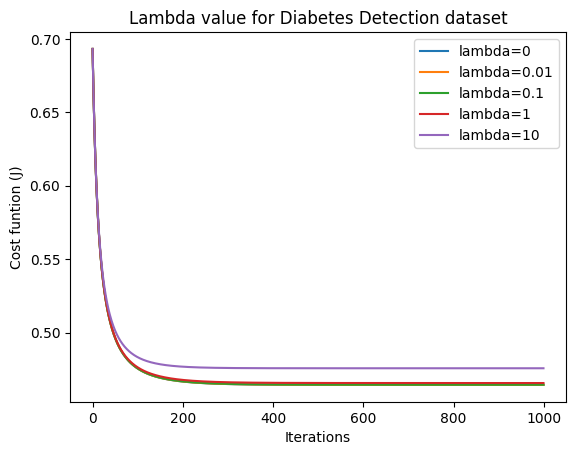

In [13]:
a = 0.1 #choosing it from the graph which one convergest the fastest

lambda_set = [0, 0.01, 0.1, 1, 10]

m, n = X.shape

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train(X, y, a, m, lambdaa):
    w = np.zeros(n)
    b = 0
    cl = []
    for i in range(iters):
        z = np.dot(X,w) + b
        p = sigmoid(z)
        dz = p-y
        dw = (1/m)*np.dot(X.T,dz) + (lambdaa/m) * w
        db = (1/m)*np.sum(dz)
        w -= a*dw
        b -= a*db
        j = -(1/m)*np.sum(y*np.log(p) + (1 - y)*np.log(1-p)) + (lambdaa / (2*m)) * np.sum(w*w)
        cl.append(j)
    return cl, w, b


iters = 1000

for lambdaa in lambda_set:
    cl, w, b = train(X, y, a, m, lambdaa)
    print(f"lambda = {lambdaa}")
    print(f"b = {b}")
    print(f"w = {w}",)
    print()
    plt.plot(range(iters), cl, label=f'lambda={lambdaa}')

plt.xlabel('Iterations')
plt.ylabel('Cost funtion (J)')
plt.title('Lambda value for Diabetes Detection dataset')
plt.legend()
plt.savefig('Lambda_tuning.png')


In [14]:
a = 0.1

cl, w, b = train(X, y, a, m, lambdaa=0.1)

df = pd.read_csv('diabetes_test.csv')

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols] = df[cols].replace(0, np.nan)
df.fillna(df.mean(), inplace=True)


x1_t=df["Pregnancies"].to_numpy()
x2_t= df['Glucose'].to_numpy()
x3_t= df['BloodPressure'].to_numpy()
x4_t= df['SkinThickness'].to_numpy()
x5_t= df['Insulin'].to_numpy()
x6_t= df['BMI'].to_numpy()
x7_t= df['Age'].to_numpy()
x8_t= df['DiabetesPedigreeFunction'].to_numpy()
X_t = np.column_stack((x1_t,x2_t,x3_t,x4_t,x5_t,x6_t,x7_t,x8_t))

y_t=df["Outcome"].to_numpy()

X_t=(X_t-mu)/sd

m,n=X_t.shape

def sigmoid(z_t):
    return 1 / (1 + np.exp(-z_t))

z_t = np.dot(X_t, w) + b
p = sigmoid(z_t)

y_pred = []
for h in p:
    if h >= 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

y_pred = np.array(y_pred)

crct = 0
for i in range(len(y_pred)):
    if y_pred[i] == y_t[i]:
        crct += 1

accuracy = np.mean(y_pred == y_t)

print("Correct predictions:", crct)
print("Total samples:", len(y_t))
print(f"Accuracy: {accuracy * 100:.4f}%")

Correct predictions: 121
Total samples: 154
Accuracy: 78.5714%


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('diabetes_dataset.csv')

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols] = df[cols].replace(0, np.nan)
df.fillna(df.mean(), inplace=True)

X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(C=0.1, max_iter=10000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print(f"SciKit learn Accuracy is : {accuracy * 100:.4f}%")

SciKit learn Accuracy is : 76.6234%
